In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ── Define IoUMetric directly (no import needed) ──
class IoUMetric(tf.keras.metrics.Metric):
    def __init__(self, name="iou", **kwargs):
        super().__init__(name=name, **kwargs)
        self.iou_sum = self.add_weight(name="iou_sum", initializer="zeros")
        self.count   = self.add_weight(name="count",   initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        ix1 = tf.maximum(y_true[:,0], y_pred[:,0])
        iy1 = tf.maximum(y_true[:,1], y_pred[:,1])
        ix2 = tf.minimum(y_true[:,2], y_pred[:,2])
        iy2 = tf.minimum(y_true[:,3], y_pred[:,3])
        inter = tf.maximum(0.0, ix2-ix1) * tf.maximum(0.0, iy2-iy1)
        area_t = (y_true[:,2]-y_true[:,0]) * (y_true[:,3]-y_true[:,1])
        area_p = (y_pred[:,2]-y_pred[:,0]) * (y_pred[:,3]-y_pred[:,1])
        iou = inter / (area_t + area_p - inter + 1e-7)
        self.iou_sum.assign_add(tf.reduce_sum(iou))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.iou_sum / self.count

    def reset_state(self):
        self.iou_sum.assign(0.0)
        self.count.assign(0.0)

# ── Load all 4 saved models ──
models = {}
model_paths = {
    "Adam":    "../outputs/best_model_Adam.keras",
    "SGD":     "../outputs/best_model_SGD.keras",
    "RMSprop": "../outputs/best_model_RMSprop.keras",
    "Adagrad": "../outputs/best_model_Adagrad.keras",
}

for name, path in model_paths.items():
    try:
        models[name] = tf.keras.models.load_model(
            path,
            custom_objects={"IoUMetric": IoUMetric},
            compile=False
        )
        print(f"✅ Loaded {name}")
    except:
        print(f"❌ Not found yet: {name} — train this optimizer first")



✅ Loaded Adam
✅ Loaded SGD
✅ Loaded RMSprop
✅ Loaded Adagrad


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os

# ── Config ──
IMG_SIZE   = 224
TRAIN_DIR  = "../data/training_images"
ANNOT_FILE = "../data/train_solution_bounding_boxes (1).csv"

# ── Load annotations ──
df = pd.read_csv(ANNOT_FILE)
df.columns = [c.strip().lower() for c in df.columns]
df_grouped = (
    df.groupby("image")
      .agg(xmin=("xmin","min"), ymin=("ymin","min"),
           xmax=("xmax","max"), ymax=("ymax","max"))
      .reset_index()
)

# ── Load images + bboxes ──
X, Y = [], []
orig_w, orig_h = 676, 380

for _, row in df_grouped.iterrows():
    try:
        img_path = os.path.join(TRAIN_DIR, row["image"])
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = img_to_array(img) / 255.0
        bbox = [
            row["xmin"] / orig_w,
            row["ymin"] / orig_h,
            row["xmax"] / orig_w,
            row["ymax"] / orig_h,
        ]
        X.append(img)
        Y.append(bbox)
    except:
        pass

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

# ── Split (same seed as training) ──
X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"✅ Val set ready — {len(X_val)} images")

✅ Val set ready — 71 images


In [5]:
results_summary = {}

for name, model in models.items():
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[IoUMetric(), "mae"]
    )
    loss, iou, mae = model.evaluate(X_val, y_val, verbose=0)
    results_summary[name] = {
        "val_loss": round(loss, 4),
        "val_iou":  round(iou,  4),
        "val_mae":  round(mae,  4),
    }
    print(f"{name:<10} → Loss: {loss:.4f}  IoU: {iou:.4f}  MAE: {mae:.4f}")



Adam       → Loss: 0.0438  IoU: 0.1968  MAE: 0.1397
SGD        → Loss: 0.0439  IoU: 0.1427  MAE: 0.1479
RMSprop    → Loss: 0.0438  IoU: 0.1751  MAE: 0.1387
Adagrad    → Loss: 0.0604  IoU: 0.0000  MAE: 0.1968


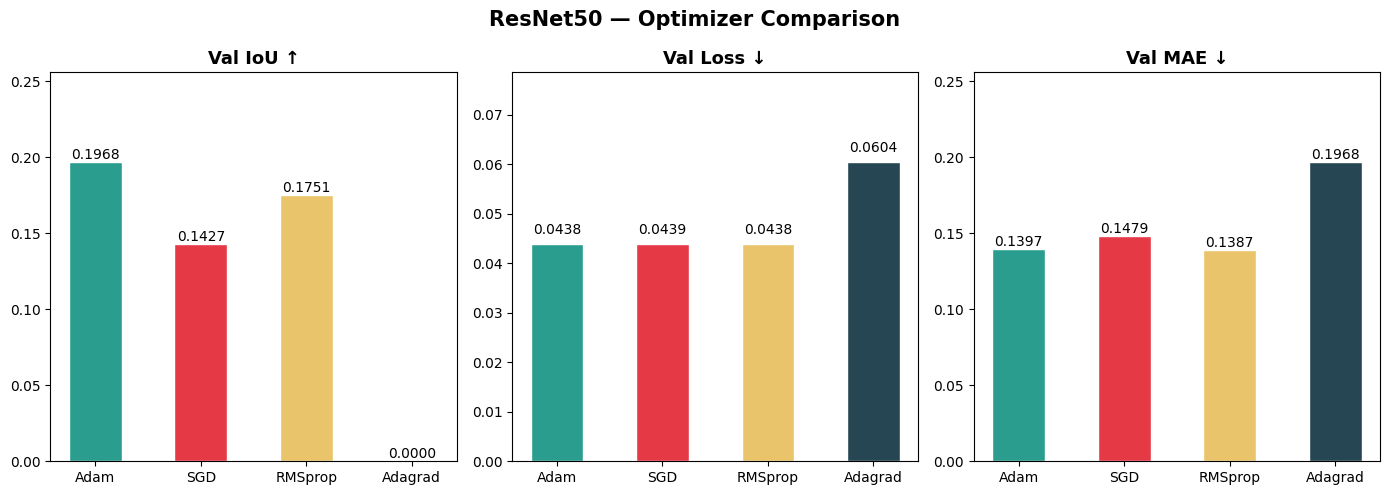

✅ Saved → outputs/final_comparison.png


In [6]:
names  = list(results_summary.keys())
ious   = [results_summary[n]["val_iou"]  for n in names]
losses = [results_summary[n]["val_loss"] for n in names]
maes   = [results_summary[n]["val_mae"]  for n in names]

colors = ["#2A9D8F", "#E63946", "#E9C46A", "#264653"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, values, title in zip(axes,
                              [ious, losses, maes],
                              ["Val IoU ↑", "Val Loss ↓", "Val MAE ↓"]):
    bars = ax.bar(names, values, color=colors[:len(names)],
                  edgecolor="white", width=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", fontsize=10)

plt.suptitle("ResNet50 — Optimizer Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/final_comparison.png")

Using best model: Adam
1/1 [==============================] - 3s 3s/step


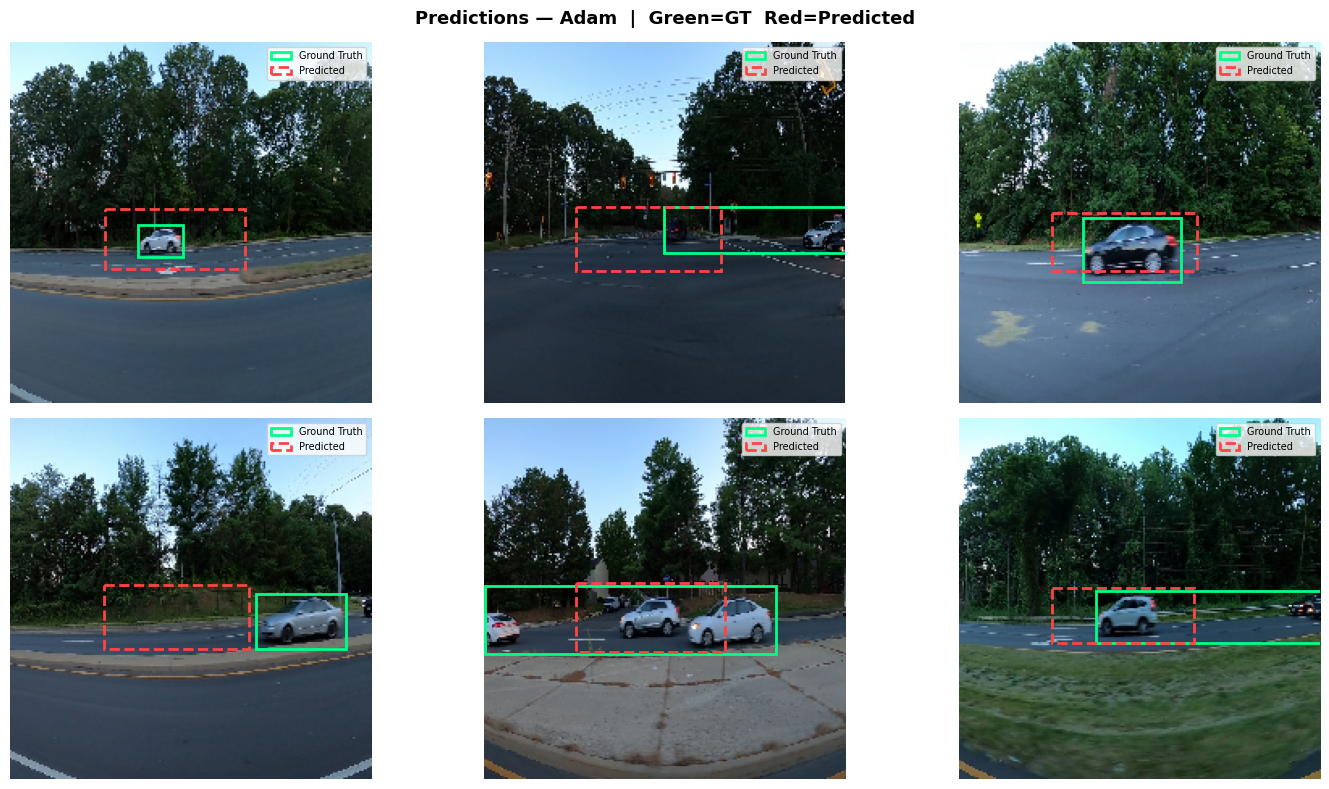

✅ Saved → outputs/sample_predictions.png


In [7]:
import matplotlib.patches as patches

# Use the best available model
best_name = max(results_summary, key=lambda x: results_summary[x]["val_iou"])
best_model = models[best_name]
print(f"Using best model: {best_name}")

preds = best_model.predict(X_val[:6])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    img = X_val[i]
    h, w = img.shape[:2]
    ax.imshow(img)

    # Ground truth (green)
    gt = y_val[i]
    ax.add_patch(patches.Rectangle(
        (gt[0]*w, gt[1]*h), (gt[2]-gt[0])*w, (gt[3]-gt[1])*h,
        linewidth=2, edgecolor="#00FF88", facecolor="none", label="Ground Truth"
    ))

    # Prediction (red)
    pr = preds[i]
    ax.add_patch(patches.Rectangle(
        (pr[0]*w, pr[1]*h), (pr[2]-pr[0])*w, (pr[3]-pr[1])*h,
        linewidth=2, edgecolor="#FF4444", facecolor="none",
        linestyle="--", label="Predicted"
    ))
    ax.legend(fontsize=7)
    ax.axis("off")

plt.suptitle(f"Predictions — {best_name}  |  Green=GT  Red=Predicted",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/sample_predictions.png")

In [8]:
best = max(results_summary, key=lambda x: results_summary[x]["val_iou"])

print("\n" + "="*45)
print("  ResNet50 Optimizer Comparison — Results")
print("="*45)
for name in results_summary:
    marker = "🏆" if name == best else "  "
    r = results_summary[name]
    print(f"{marker} {name:<10} IoU: {r['val_iou']:.4f}  "
          f"Loss: {r['val_loss']:.4f}  MAE: {r['val_mae']:.4f}")
print("="*45)
print(f"\n✅ Best Optimizer: {best}")
print(f"   IoU  : {results_summary[best]['val_iou']}")
print(f"   Loss : {results_summary[best]['val_loss']}")
print(f"   MAE  : {results_summary[best]['val_mae']}")


  ResNet50 Optimizer Comparison — Results
🏆 Adam       IoU: 0.1968  Loss: 0.0438  MAE: 0.1397
   SGD        IoU: 0.1427  Loss: 0.0439  MAE: 0.1479
   RMSprop    IoU: 0.1751  Loss: 0.0438  MAE: 0.1387
   Adagrad    IoU: 0.0000  Loss: 0.0604  MAE: 0.1968

✅ Best Optimizer: Adam
   IoU  : 0.1968
   Loss : 0.0438
   MAE  : 0.1397
